Please run the cell below to import libraries needed for this HW. Please use the autograd numpy, otherwise you will have issues. Please remember to always use the np library for mathematical functions (e.g., np.log, np.exp, np.sum, etc)

In [19]:
import autograd.numpy as np
from autograd import grad 
import matplotlib.pyplot as plt
%matplotlib inline

Q1) [5 points] Implement the sigmod funcation discussed in class. The function takes a value, x, as input and returns the sigmoid function applied to the value.

In [20]:
def sigmoid(x):
    #Your code here
    y = 1/(1 + np.exp(-x))
    return y

Q2) [20 points] Implement the logistic regression cross entropy cost discussed in class. Note that the logistic regression cross entropy cost relies on the sigmoid function (which you have implemented above) and the linear  model (which you have implemented in HW2). You can use the linear model from HW2 for this problem. Similar to the least-squares cost from HW2, the cross entropy cost takes in as input an array of weights, w, an array of x's and an array of ys and return a float indicating the total cost. Again, the logistic regression cross entropy function should use the sigmoid and model functions already implemented.

In [21]:
#Your linear model from HW2
def model(x,w):
    #Your code here
    y1 = w[0] + np.dot(np.transpose(x),w[1:])
    y = np.transpose(y1)
    return y

#The logistic regression cross entropy cost
def LR_cross_entropy(w,x,y):
    #Your code here
    p = y.size # get number of points
    sig_mod = sigmoid(model(x,w))
    
    # find the cost for where y = 1
    y1 = np.argwhere(y==1)
    # Extract the index for these value
    index1 = y1[:,1]
    cost = np.sum(np.log(sig_mod[index1]))
    # Find for where y = 0 and extract index
    y0 = np.argwhere(y==0)
    index0 = y0[:,1]
    cost += np.sum(np.log(1 - sig_mod[index0]))
    
    cost = -1*cost/p
    return cost

Q3) [2 points] Run the code below to read a data file. Plot a scatter plot of x vs y.

Text(0.5, 1.0, '2d_classification Scatter Plot')

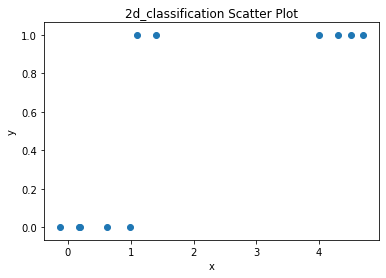

In [24]:
csvname = '2d_classification_data_v1_entropy.csv'
data = np.loadtxt(csvname,delimiter = ',')
x = data[:-1,:]
y = data[-1:,:] 
plt.scatter(x,y)
plt.xlabel('x')
plt.ylabel('y')
plt.title("2d_classification Scatter Plot")

Q4) [10 points] Move the gradient descent function from HW2. Run the function on the cross_entropy cost using the x and y from above and the parameters set to: max_its=2000,w=[3.0,3.0 ], and alpha=1. Save the cost and weight history returned by the gradient descent function. Plot the cost history.


In [25]:
##gradient descent from HW2
def gradient_descent(g,alpha,max_its,w,x,y):
    #Your code here
    # get the gradient for the function
    gradient = grad(g)
    
    # build weight and cost history
    weight_history = []
    cost_history = []
    
    # iterate and keep track of weight and cost 
    for i in range(max_its):
        weight_history.append(w)
        cost_history.append(g(w,x,y))
        w = w - alpha*gradient(w,x,y) # descend in steepest direction
    return weight_history,cost_history



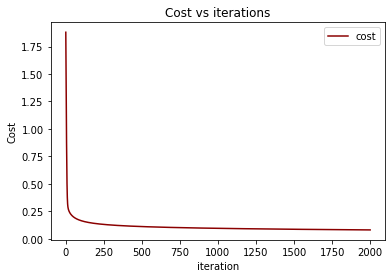

In [60]:
##Call the gradient_descent function here
max_its = 2000;
w = np.array([3.0,3.0])
alpha = 1
w_hist, c_hist = gradient_descent(LR_cross_entropy,alpha,max_its,w,x,y)

##Plot the cost history here
# iteration list for plotting
i = [x+1 for x in range(max_its)]
plt.plot(i,c_hist,label = 'cost',color = 'darkred')
plt.xlabel('iteration')
plt.ylabel('Cost')
plt.title("Cost vs iterations")
plt.legend()

Q5) [10 points] Implement a logistic regression classifier that takes in the learned weights and x as input and returns the probability of the positive class (note that this is just the output of the sigmoid applied to the linear combination of the x and w)

In [61]:
def logistic_regression(learned_w,x):
    #your code here
    yp = model(x,learned_w)
    positive_class_prob = sigmoid(yp)
    return positive_class_prob

Q6) [5 points] Use the learned weights from the last gradient descent run and the logistic regression function implemented above to plot the learned curve. You can use the linspace method (shown below) to generate a list of xs that you can use. You need to generate a y for each of the candidate xs using the logistic regression function and the learned weights. On the same figure, also plot the scatter plot from Q3. 


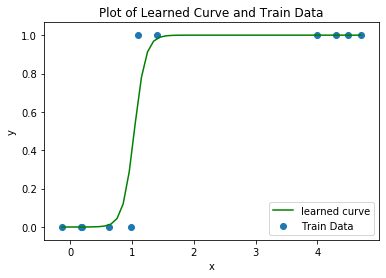

In [63]:
s = np.linspace(np.min(x),np.max(x))
#Your code here
learned_w =  w_hist[-1]
y_list = []
for i in range(len(s)):
    y_list.append(logistic_regression(learned_w,s[i]))
    
plt.plot(s,y_list,label='learned curve',color = 'green')
plt.scatter(x,y,label = 'Train Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Plot of Learned Curve and Train Data")
plt.legend()

Q7) [5 points] Slightly modify the logistic regression model above so that it returns a 1 or 0 based on the specified threshold.

In [64]:
def logistic_regression_modified(learned_w,x, threshold):
    #your code here
    y = model(x,learned_w)
    positive_class_prob = sigmoid(y)
    if (positive_class_prob >= threshold):
        class_label = 1.0
    else:
        class_label = 0.0
    return class_label

Q8) [15 points] Write a function (called evaluate) that takes in actual and predicted ys (for a binary classification problem) and return a confusion matrix and the accuracy. Use the modified logistic regression model and the evaluate function below to report the confusion matrix and accuracy for the x and y used for our training at a threshold of 0.5.  

In [65]:
def evaluate(y_actual,y_pred):
    ## Your code here
    ## compare actual and predicted and build : y_actual and Y_pred are lists
    false_positive = false_negative = true_positive = true_negative = accuracy = 0
    for i in range(len(y_pred)):
        
        if y_pred[i] == 0:
            if y_actual[0][i] == 0:
                true_negative += 1
            elif y_actual[0][i] == 1:
                false_negative += 1
                
        elif y_pred[i] == 1:
            if y_actual[0][i] == 0:
                false_postive += 1
            elif y_actual[0][i] == 1:
                true_positive += 1
                
    accuracy = (true_positive/(true_positive + false_positive))/2 + (true_negative/(true_negative+false_negative))/2
   
    return false_positive, false_negative, true_positive, true_negative, accuracy

In [66]:
# create predicted values
threshold = 0.5
y_pred = []
for i in range(y.size):
    y_pred.append(logistic_regression_modified(learned_w,x[0][i], threshold))
    
evaluation = evaluate(y,y_pred)
print(evaluation)
print("False Positive = ",evaluation[0])
print("False Negative = ",evaluation[1])
print("True Positive = ",evaluation[2])
print("True Negative = ",evaluation[3])
print("Accuracy",evaluation[4])

(0, 0, 6, 5, 1.0)
False Positive =  0
False Negative =  0
True Positive =  6
True Negative =  5
Accuracy 1.0


## The rest of these problems are for bonus points

Q9) [20 points] Implement the perceptron cost function from the class (the softmax version). Note that the perceptron cost also uses the linear model (the model function from question 2).

In [70]:
def perceptron_cost(w,x,y):    
   #Your code here
    # first convert all 0 class to -1 class
    yp = np.where(y==0, -1, y)
    ## linear model
    lin_mod = model(x,w)
    cost = np.sum(np.log(1 + np.exp(-yp*lin_mod)))
    return cost

Q10) [10 points] Run gradient descent function on the perceptron cost using the x and y from above and the parameters set to: max_its=2000,w=[1.0,1.0], and alpha=10. Save the cost and weight history returned by the gradient descent function. Plot the cost history. Which cost seems to do better on this dataset? Why do think that is?


Text(0.5, 1.0, 'Plot of Cost vs Iterations')

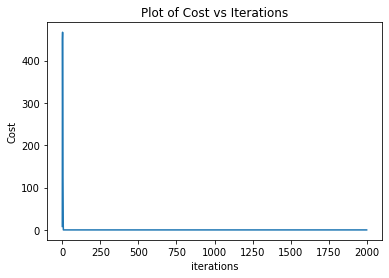

In [71]:
##Call the gradient_descent function here
alpha = 10
w = np.array([1.0,1.0])
max_its = 2000
w_hist,cost_hist = gradient_descent(perceptron_cost,alpha,max_its,w,x,y)
##Plot the cost history here
plt.plot(cost_hist)
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.title("Plot of Cost vs Iterations")

## Answer
I think the perceptron cost did better than the LR entropy cost because the perceptron has a faster rate of convergence to the minimum.
It will take fewer iterations for the perceptron cost to converge to the minimum than that of the LR entropy cost function. 
In 2000 iterations,the perceptron cost converges to 0 while the LR_entropy doesn't.
Refer to plotted graph for results of learned line.

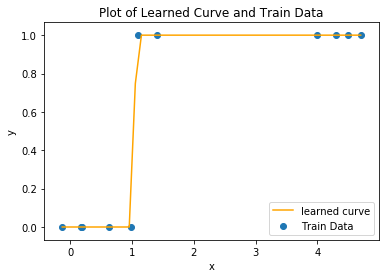

In [73]:
s = np.linspace(np.min(x),np.max(x))
#Your code here
learned_w =  w_hist[-1]
y_list = []
for i in range(len(s)):
    y_list.append(logistic_regression(learned_w,s[i]))
    
plt.plot(s,y_list,label='learned curve',color = 'orange')
plt.scatter(x,y,label = 'Train Data')
plt.xlabel('x')
plt.ylabel('y')
plt.title("Plot of Learned Curve and Train Data")
plt.legend()